In [97]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [98]:
excel_files = ['2024년 3월 고용보험 통계표(수정).xlsx',
    '2024년 6월 고용보험 통계표.xlsx',
    '2024년 9월 고용보험 통계표.xlsx',
    '2024년 12월 고용보험 통계표.xlsx',
    '2025년 3월 고용보험 통계표.xlsx',
    '2025년 6월 고용보험 통계표.xlsx',
    '2025년 9월 고용보험 통계표.xlsx',
    '2025년 12월 고용보험 통계표.xlsx',
    '2026년 3월 고용보험 통계표.xlsx']
periods = ['2024.03', '2024.06', '2024.09', '2024.12', '2025.03', '2025.06', '2025.09', '2025.12', '2026.03']


In [99]:
df_list =[]

for i in excel_files:
    df = pd.read_excel(i, sheet_name= '2-3-2')
    df_list.append(df)



In [ ]:
all_data = {}

for j in range(9):
    current_df = df_list[j]
    p = periods[j]

    j_idx = current_df[current_df.iloc[:,0].astype(str).str.contains("J.정보통신업")].index[0]
    k_idx = current_df[current_df.iloc[:, 0].astype(str).str.contains('K.금융')].index[0]

    sub_df = current_df.iloc[j_idx:k_idx].copy()

    for inx, row in sub_df.iterrows():
        subcat = row.iloc[2]
        val = row.iloc[3]

        # 값이 비어있지 않으면 실행
        if pd.notna(subcat):
            subcat_clean = str(subcat).strip() #이건 문자열 정리. 공백 제거
            val_clean = int(val) if pd.notna(val) else 0 #값 있으면 정수로 변환 없으면 0 넣기

            if subcat_clean not in all_data: #딕셔너리 생성 여부 확인 
                all_data[subcat_clean] = {}
            all_data[subcat_clean][p] = val_clean #예시 subcat_clean = "SW개발" p = "2024.03" val_clean = 52000 이면  all_data["SW개발"]["2024.03"] = 52000 이케 됨
      
    ''' 딕셔너리가 이렇게 됨 
    "SW개발": {
        "2024.03": 52000,
        "2024.06": 53000
    }  
    '''


            
final_df = pd.DataFrame(all_data).T
final_df.to_excel("정보통신업_소분류_최종시계열.xlsx")
print("최종 테이블 가공 및 엑셀 저장 완료!")

최종 테이블 가공 및 엑셀 저장 완료!


In [101]:
df = pd.read_excel("정보통신업_소분류_최종시계열.xlsx")
df = df.rename(columns={'Unnamed: 0': '산업분류'})
df = df.set_index('산업분류')

df

,2024.03,2024.06,2024.09,2024.12,2025.03,2025.06,2025.09,2025.12,2026.03
산업분류,,,,,,,,,
"581.서적, 잡지 및 기타 인쇄물 출판업",111155,114905,115735,115879,114505,117685,119289,122204,48221
582.소프트웨어 개발 및 공급업,52307,51880,51260,50771,49993,49471,48954,48629,446112
"591.영화, 비디오물, 방송 프로그램 제작 및 배급업",447107,448691,449656,445909,444074,445835,449610,447606,42317
592.오디오물 출판 및 원판 녹음업,44810,45557,45026,43597,42619,42947,43210,42972,2482
601.라디오 방송업,2553,2536,2506,2514,2530,2575,2610,2512,1549
602.텔레비전 방송업,1666,1632,1626,1595,1572,1589,1584,1570,20250
611.공영 우편업,20700,20578,20534,20408,20184,20229,20287,20265,5369
612.전기 통신업,5345,5340,5271,5452,5406,5423,5351,5414,59875
"620.컴퓨터 프로그래밍, 시스템 통합 및 관리업",65441,65087,64654,62009,61786,61522,61191,60322,73687


In [102]:
#3월달 데이터 문제 발견 한 칸식 밀림 문제 이상치 발견 재배열
df.loc['581.서적, 잡지 및 기타 인쇄물 출판업','2026.03'] = 124176  
df.loc['582.소프트웨어 개발 및 공급업','2026.03'] = 48221
df.loc['591.영화, 비디오물, 방송 프로그램 제작 및 배급업','2026.03'] = 446112
df.loc['592.오디오물 출판 및 원판 녹음업','2026.03'] = 42317
df.loc['601.라디오 방송업','2026.03'] = 2482
df.loc['602.텔레비전 방송업', '2026.03'] = 1549
df.loc['611.공영 우편업', '2026.03'] = 20250 
df.loc['612.전기 통신업', '2026.03'] = 5369
df.loc['620.컴퓨터 프로그래밍, 시스템 통합 및 관리업', '2026.03'] = 59875
df.loc['631.자료 처리, 호스팅, 포털 및 기타 인터넷 정보 매개 서비스업', '2026.03'] = 73687
df.loc['639.기타 정보 서비스업', '2026.03'] = 19585

df

,2024.03,2024.06,2024.09,2024.12,2025.03,2025.06,2025.09,2025.12,2026.03
산업분류,,,,,,,,,
"581.서적, 잡지 및 기타 인쇄물 출판업",111155,114905,115735,115879,114505,117685,119289,122204,124176
582.소프트웨어 개발 및 공급업,52307,51880,51260,50771,49993,49471,48954,48629,48221
"591.영화, 비디오물, 방송 프로그램 제작 및 배급업",447107,448691,449656,445909,444074,445835,449610,447606,446112
592.오디오물 출판 및 원판 녹음업,44810,45557,45026,43597,42619,42947,43210,42972,42317
601.라디오 방송업,2553,2536,2506,2514,2530,2575,2610,2512,2482
602.텔레비전 방송업,1666,1632,1626,1595,1572,1589,1584,1570,1549
611.공영 우편업,20700,20578,20534,20408,20184,20229,20287,20265,20250
612.전기 통신업,5345,5340,5271,5452,5406,5423,5351,5414,5369
"620.컴퓨터 프로그래밍, 시스템 통합 및 관리업",65441,65087,64654,62009,61786,61522,61191,60322,59875


In [ ]:
#필요없는 로우 삭제

drop_targets = [
    '581.서적, 잡지 및 기타 인쇄물 출판업',
    '591.영화, 비디오물, 방송 프로그램 제작 및 배급업',
    '592.오디오물 출판 및 원판 녹음업',
    '601.라디오 방송업',
    '602.텔레비전 방송업',
    '611.공영 우편업',
    '612.전기 통신업',
    
]
df = df.drop(drop_targets, axis=0, errors='ignore')
df

,2024.03,2024.06,2024.09,2024.12,2025.03,2025.06,2025.09,2025.12,2026.03
산업분류,,,,,,,,,
582.소프트웨어 개발 및 공급업,52307,51880,51260,50771,49993,49471,48954,48629,48221
"620.컴퓨터 프로그래밍, 시스템 통합 및 관리업",65441,65087,64654,62009,61786,61522,61191,60322,59875
"631.자료 처리, 호스팅, 포털 및 기타 인터넷 정보 매개 서비스업",70981,71046,71524,71661,72261,72863,73210,73026,73687
639.기타 정보 서비스업,19733,19773,19632,19442,19355,19474,19738,19822,19585


In [104]:
final_dataframe = pd.DataFrame(df).T
final_df.to_excel("데이터 완료.xlsx")

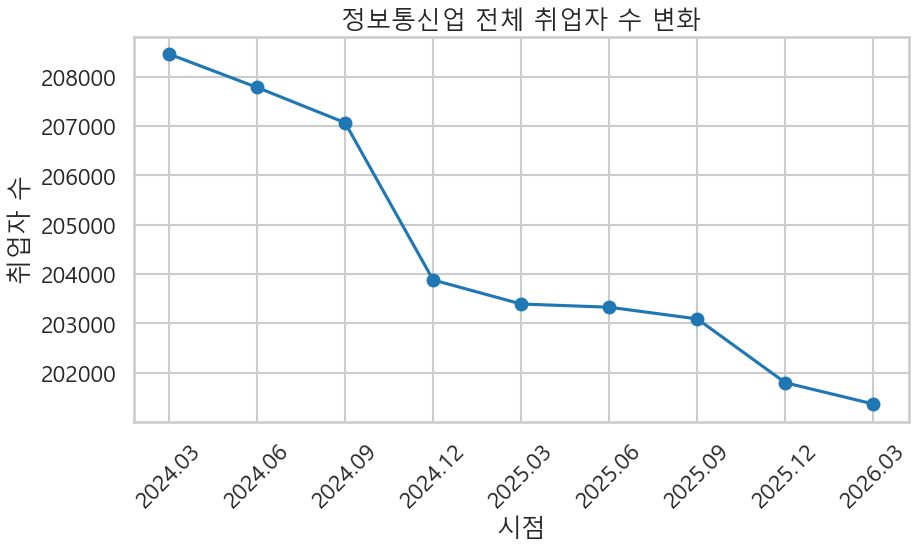

In [105]:
total = df.sum(axis=0)
sns.set_context("talk")

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(10,5))
plt.plot(total.index, total.values, marker='o')


plt.title('정보통신업 전체 취업자 수 변화')
plt.xlabel('시점')
plt.ylabel('취업자 수')

plt.xticks(rotation=45)
plt.grid(True)

plt.show()


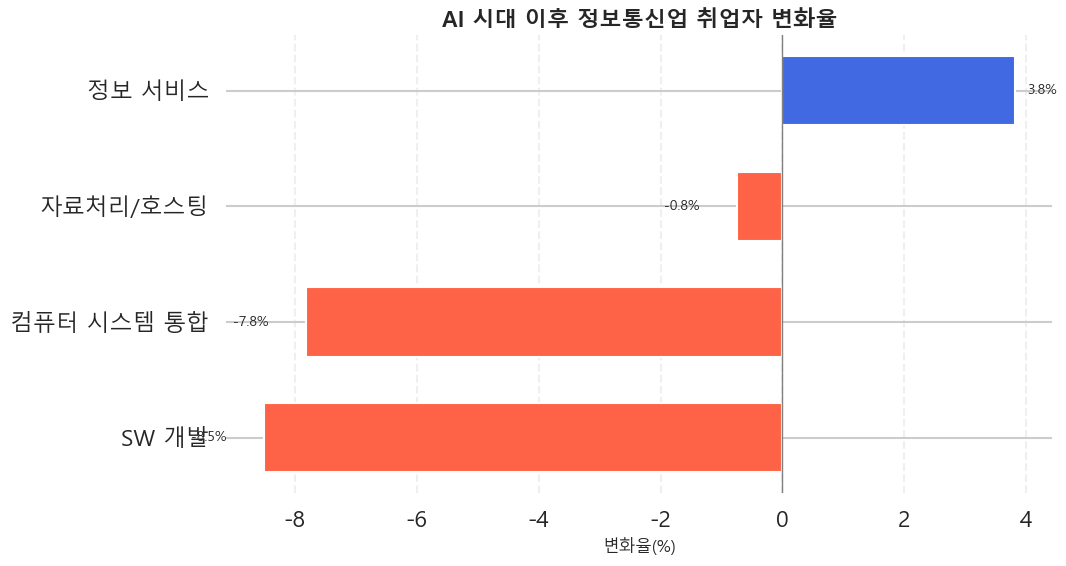

In [106]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_context("talk")
change_rate = (
    (df['2026.03'] - df['2024.03'])
    / df['2024.03']
) * 100

change_rate = change_rate.sort_values()

# 이름 간단하게
labels = [
    'SW 개발',
    '컴퓨터 시스템 통합',
    '자료처리/호스팅',
    '정보 서비스'
]

# 색상
colors = ['tomato' if x < 0 else 'royalblue' for x in change_rate.values]

plt.figure(figsize=(11,6))

bars = plt.barh(
    labels,
    change_rate.values,
    color=colors,
    height=0.6
)

# 0 기준선
plt.axvline(0, color='gray', linewidth=1)

# 값 표시
for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 0.2 if width > 0 else width - 1.2,
        bar.get_y() + bar.get_height()/2,
        f'{width:.1f}%',
        va='center',
        fontsize=10
    )

# 스타일
plt.title(
    'AI 시대 이후 정보통신업 취업자 변화율',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('변화율(%)', fontsize=12)

# 위/오른쪽 테두리 제거
plt.box(False)

# 연한 가로선
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()

plt.show()